<a href="https://colab.research.google.com/github/tlamadon/abc-of-akm/blob/main/jep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello, this is a notebook associated with the JEP article on the ABC of AKM. We provide simple simulation examples to make concrete the different points developed in the paper.

The first part is a quick dive in, while later section go behind the scene, explaining how the data is generated and diggs deeper in the analysis.

The notebook is fully self contained and you can look directly at all the code. Some of it is a bit lengthy so the code cell is closed to start with.

We hope this is useful and please provide any feedback directly to us.

TODO:
1. constructive example about between firm difference in wages versus wage gains in a move (using movers)
 - 1) simulate a network
 - 2) construct the outcome equation explicitely
 - 3) define the object of interest (as in the paper)
 - 4) show that difference in mean doesn't recover
 - 5) show that AKM does recover such difference
2. the bias example, also do 2 parametrizations.

In [1]:
# @title Simulation code (hidden for quick dive)
# we generate a simple homophily network
# that we can later use to simulate data

# !apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.sparse import coo_matrix

import networkx as nx
import pandas as pd

import graphviz
from graphviz import Digraph
from IPython.display import Image
from IPython.display import display, Markdown

from string import Template

# plt.rcParams['text.usetex'] = True # TeX rendering
# plt.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams['font.family'] = 'STIXGeneral'

class Param:
    def __init__(self, **kwds):
        self.__dict__.update({
            'rho':1.0,
            'lambda1':0.1,
            'sigma':0.2,
            'ng':10,
            'nj':20
            })
        self.__dict__.update(kwds)
    def __str__(self):
      return(' '.join(f'{key}={value}' for key, value in self.__dict__.items()))
    def __repr__(self):
      return(str(self))

def matrix_stationary_distribution(transition_matrix):
    # Compute the eigenvalues and eigenvectors of the transposed transition matrix
    eigvals, eigvecs = np.linalg.eig(transition_matrix.T)

    # Find the eigenvector corresponding to the eigenvalue 1
    stationary_vec = eigvecs[:, np.isclose(eigvals, 1)]

    # Normalize the vector to make it a probability distribution (sums to 1)
    stationary_dist = stationary_vec[:, 0].real
    stationary_dist = np.maximum(0, np.sign(stationary_dist.sum()) * stationary_dist)
    stationary_dist /= stationary_dist.sum()

    return stationary_dist

# def matrix_to_latex():
#   # Convert the numpy array to a LaTeX matrix string
#   latex_matrix = r"\begin{bmatrix}" + "\n"
#   for row in array:
#       row_str = " & ".join(map(str, row))  # Convert each row to a LaTeX-friendly string
#       latex_matrix += row_str + r" \\" + "\n"  # Add line breaks for each row
#   latex_matrix += r"\end{bmatrix}"

def make_connected(dataset):
  I = dataset['i'].to_numpy()
  J = dataset['j'].to_numpy()

  G = nx.Graph()
  for ii in range(1,len(I)):
    if (I[ii] != I[ii-1]):
      continue
    if (J[ii] != J[ii-1]):
      G.add_edge(J[ii-1], J[ii])

  # Find all connected components and identify the largest one
  largest_component = max(nx.connected_components(G), key=len)

  # Convert the set to a list or keep as a set, as desired
  largest_component_list = list(largest_component)

  print("Largest connected component:", len(largest_component_list))

  # we remove these firms and reindex them
  dfc = dataset[dataset['j'].isin(largest_component_list)]
  dfc.loc[:,'j'] = pd.factorize(dfc['j'])[0]
  dfc.loc[:,'i'] = pd.factorize(dfc['i'])[0]
  return(dfc)

def data_to_matrix(dataset, normalize=False):
  dataset = dataset.sort_values(by=['i', 't'])
  I = dataset['i'].to_numpy()
  J = dataset['j'].to_numpy()

  nn = len(I)
  nj = len(np.unique(J))
  ni = len(np.unique(I))
  Af = np.zeros((nn, nj-1)) # normalizes last firm to 0
  Aw = np.zeros((nn, ni))
  for n in range(nn):
    if J[n]<nj-1:
      Af[n, J[n]] = 1
    Aw[n, I[n]] = 1
  M = np.hstack((Af,Aw))
  return(M,Af,Aw)

class Model:
  def __init__(self, p):
    self.lambda1 = p.lambda1
    self.sigma = p.sigma
    self.rho = p.rho
    self.psi_j   = norm.ppf(np.linspace(1/p.nj,1-1/p.nj,p.nj), loc=0, scale=1.0)
    self.alpha_g = norm.ppf(np.linspace(1/p.ng,1-1/p.ng,p.ng), loc=0, scale=1.0)
    self.ng=p.ng
    self.nj=p.nj
    self.H = None

  # this is the transition probability between psi_j1 and psi_j2 for worker type gamma
  def tr_pr(self, alpha, psi1, psi2):
    return self.lambda1 * 1 / (1 + np.exp( 1/self.rho * ( (psi2-alpha)**2  - (psi1-alpha)**2 )))

  def construct_transition_matrix(self, alpha, psi):
      n = len(psi)
      transition_matrix = np.zeros((n, n))

      # Calculate the unnormalized transition probabilities
      for j in range(n):
          for jp in range(n):
              transition_matrix[j, jp] = self.tr_pr(alpha, psi[j], psi[jp])

      # Normalize each row to make it a valid probability distribution
      row_sums = transition_matrix.sum(axis=1, keepdims=True)
      transition_matrix /= row_sums

      return transition_matrix

  def stationary_distribution(self):
    ng = len(self.alpha_g)
    nj = len(self.psi_j)
    H = np.zeros((self.ng, self.nj))
    for g in range(ng):
      transition_matrix = self.construct_transition_matrix(self.alpha_g[g], self.psi_j)
      H[g,:] = matrix_stationary_distribution(transition_matrix)
    self.H = H
    return(H)

  def equilibrium_wages(self):
    W = np.zeros((self.ng, self.nj))
    for g in range(self.ng):
      for j in range(self.nj):
        W[g,j] = self.alpha_g[g] + self.psi_j[j]
    return(W)

  def draw_residuals(self,dataset):
    dataset['epsilon'] = np.random.normal(0, 1, len(dataset)) * self.sigma
    dataset['w']       = dataset['alpha'] + dataset['psi'] + dataset['epsilon']
    return(dataset)

  def simulate(self, ni, nt, connected=False):

    # make sure we have the stationary distribution
    if self.H is None:
      self.stationary_distribution()

    data = []
    moves = 0
    ng = len(self.alpha_g)
    nj = len(self.psi_j)

    # Iteratively generate and append data
    for i in range(ni):  # Replace with the number of iterations or conditions
        # Example data: each row contains two values

        g = np.random.choice(range(ng), size=1)[0]
        j = np.random.choice(range(nj), size=1, p=self.H[g,:])[0]
        t = 0
        alpha_i = self.alpha_g[g] + np.random.normal(0, 1)
        row = {'i': i, 'j': j, 't':0, 'alpha':alpha_i}
        data.append(row)

        # got over time
        for t in range(1,nt):
          j2 = np.random.choice(range(nj), size=1)[0]
          pr_move = self.tr_pr(self.alpha_g[g] , self.psi_j[j], self.psi_j[j2])
          if (j != j2) and (np.random.uniform(low=0, high=1) < pr_move ):
            j = j2
            moves = moves+1
          row = {'i': i, 'j': j, 't':t, 'alpha':alpha_i}
          data.append(row)

    # Convert to a DataFrame
    dataset = pd.DataFrame(data)
    dataset['psi']     = self.psi_j[dataset['j']]
    dataset = self.draw_residuals(dataset)

    if connected:
      dataset = make_connected(dataset)

    return(dataset)

  def plot_wages_and_distribution(self):
    H = model.stationary_distribution()
    W = model.equilibrium_wages()

    palette =sns.mpl_palette("tab10", 10)  # Example: husl palette with 5 colors
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    bottom = np.zeros(H.shape[1])
    H2 = H / H.sum(axis=0)
    for i in range(H.shape[0]):
        axes[0].fill_between(model.psi_j, bottom, bottom + H2[i,:])
        bottom += H2[i,:]

    axes[1].plot(model.psi_j,W.transpose());
    return fig, axes

def variance_decomposition(data):
  pass

def compute_akm(dataset):
  M, Af, Aw = data_to_matrix(dataset)
  MM = np.matmul(M.transpose(),M)
  x = np.linalg.solve(MM, M.transpose() @ dataset['w'].to_numpy())

  psi_jt = dataset['psi'].to_numpy()
  alpha_jt = dataset['alpha'].to_numpy()
  psi_hat = Af @ x[range(Af.shape[1])]
  alpha_hat = Aw @ x[ range( Af.shape[1], Aw.shape[1]+Af.shape[1])]

  data['alpha_hat'] = alpha_hat
  data['psi_hat'] = psi_hat
  return(data)


def variance_decomposition(data, alpha_col="alpha", psi_col="psi", y_col="w", format="dict"):
  stats = {}
  # Calculate the variance of 'alpha'
  stats["var_alpha"] = data[alpha_col].var()
  stats["var_psi"] = data[psi_col].var()
  stats["cov_alpha_psi"] =  data[alpha_col].cov(data[psi_col])
  eps = data[y_col] - data[alpha_col] - data[psi_col]
  stats["var_eps"] = eps.var()
  return stats

def format_variance_decomposition(stats, text=""):
  template = Template(r"""
    $addition_content:

    \begin{array}{c c c c}
    Var(\alpha) & Var(\psi) & 2 Cov(\alpha,\psi)  & Var(\epsilon) \\
    \hline
    $var_alpha & $var_psi & $cov_alpha_psi & $var_eps \\ \hline
    \end{array}
    """)

  formatted = template.safe_substitute(
      var_alpha= "%3.2f" % stats['var_alpha'],
      var_psi= "%3.2f" % stats['var_psi'],
      cov_alpha_psi = "%3.2f" % (2*stats['cov_alpha_psi']),
      var_eps=  "%3.2f" %stats['var_eps'],
      addition_content = text
      )

  return formatted

def display_variance_decomposition(stats, text=""):
  display(Markdown(format_variance_decomposition(stats, text)))

def abline(slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

# Addressing selection using AKM when measuring the role of firms in wage inequality

We start with an example of the usefulness of the AKM framework. We simulate data with a known wage equation. In such data we are interested in understanding the role of firms in the earnings inequality between workers.

In the following data, the wage of a worker $\alpha$ employed in firm $\psi$ is given by

$$y_{it} = \alpha_i + \psi_{j_{it}} + \epsilon_{it}$$

In [2]:
np.random.seed(6344) # fixing the random seed

# create a parameter set using default values
p = Param( lambda1=0.15, rho = 0.5 , sigma=1.0, ng=10, nj=100)

# initialize the model from the parameters
model = Model(p)

# simulate data from the model, impose connectedness
data = model.simulate(1_000,5,connected=True)

data

Largest connected component: 95


,i,j,t,alpha,psi,epsilon,w
0,0,0,0,1.859599,1.648784,0.928669,4.437052
1,0,0,1,1.859599,1.648784,0.116713,3.625096
2,0,0,2,1.859599,1.648784,1.679753,5.188135
3,0,1,3,1.859599,-0.161991,0.077336,1.774944
4,0,1,4,1.859599,-0.161991,1.624839,3.322447
...,...,...,...,...,...,...,...
4995,983,47,0,0.428239,-0.448856,-0.531609,-0.552226
4996,983,47,1,0.428239,-0.448856,1.557378,1.536761
4997,983,47,2,0.428239,-0.448856,-1.567866,-1.588482
4998,983,47,3,0.428239,-0.448856,1.908651,1.888034


We can use our simulated data to compute the variance of earnings across individuals, as well as the variance of earnings across firms.

In [3]:
# Compute the mean by group and assign it to a new column
data['firm_wage'] = data.groupby('j')['w'].transform('mean')
print(f"share between firm variance        : {data['firm_wage'].var()/data['w'].var()}" )


share between firm variance        : 0.4386792897016286


We find that 37% of the total wage variance can be attributed to differences in mean wage across firms. Meaning, when looking a the cross-section of firms, firms appear to pay very different mean wages.

Of course, the main question that AKM allows to address is whether these firm mean wage differences are large because:
1. different firms employ different workers: some firms employ very skilled workers and pay them for their skills, other firms hire mainly low skill workers. All firms pay the same wage to workers of the same skill.
2. different firms all employ similar workers, but some firms pay higher wages.

To answer such question, we run the AKM regression to recover both the $\alpha$ and the $\psi$ for each worker and firm (in the connected set).

In [4]:
var_decomposition_true = variance_decomposition(data)
display_variance_decomposition(var_decomposition_true, text="True model decomposition")


    True model decomposition:

    \begin{array}{c c c c}
    Var(\alpha) & Var(\psi) & 2 Cov(\alpha,\psi)  & Var(\epsilon) \\
    \hline
    1.59 & 0.52 & 0.78 & 0.99 \\ \hline
    \end{array}
    

Using our AKM decomposition we can then decompose the between variance to understand the role of firms.

$$Var ( E[w_{it} | j] ) = Var( \psi_{j(i,t)} ) +  Var( E[\alpha_{it} | j] ) + 2 Cov(\psi_{j(i,t)},  E[\alpha_{it} | j]) $$

In [5]:
data['firm_alpha'] = data.groupby('j')['alpha'].transform('mean')
print(f"share between firm variance        : {data['firm_wage'].var()/data['w'].var()}" )
print(f"share between firm composition.    : {data['firm_alpha'].var()/data['w'].var()}" )
print(f"share between firm pay difference  : {data['psi'].var()/data['w'].var()}")
print(f"share cov between the 2.           : {np.cov(data['psi'],data['firm_alpha'])[0,1]/data['w'].var()}")


share between firm variance        : 0.4386792897016286
share between firm composition.    : 0.10429435053141504
share between firm pay difference  : 0.13705107257130691
share cov between the 2.           : 0.10356714732173934


We note that:
 - the variance decomposition does add up to the total share of between firm variance
 - the decomposition highlights that the pay difference is actually less than half of what the between firm variance would suggest.

Perhaps more importantly, we could make this example much more sever by increasing the sorting of workers to firms.

As an exercise, change the value of $\rho$ in the parameters of the model, and rerun everything. Notice that you can bring the contribution of the firm pay difference to 0.

## Quick dive, simulate and estimate AKM

We start with a quick dive, brushing over the details. We use the provided functions to create a parameter set and simulate a matched data set.

In [6]:
np.random.seed(6344) # fixing the random seed

# create a parameter set using default values
p = Param( lambda1=0.15, rho = 2.0 , sigma=1.0, ng=10, nj=100)

# initialize the model from the parameters
model = Model(p)

# simulate data from the model, impose connectedness
data = model.simulate(1_000,5,connected=True)

data

Largest connected component: 98


,i,j,t,alpha,psi,epsilon,w
0,0,0,0,1.859599,2.326348,-0.337278,3.848669
1,0,0,1,1.859599,2.326348,1.651831,5.837777
2,0,0,2,1.859599,2.326348,1.341673,5.527619
3,0,1,3,1.859599,-0.161991,0.077705,1.775313
4,0,1,4,1.859599,-0.161991,-0.106895,1.590713
...,...,...,...,...,...,...,...
4995,991,81,0,1.253955,0.504458,-2.644807,-0.886393
4996,991,81,1,1.253955,0.504458,-0.190096,1.568318
4997,991,81,2,1.253955,0.504458,-0.178008,1.580406
4998,991,81,3,1.253955,0.504458,1.291315,3.049729


The data contains is a panel of workers with the following columns:
- `i`: worker identifier
- `j`: firm identifier
- `t`: time period
- `alpha`: worker wage fixed heterogeneity
- `psi`: firm wage fixed heterogeneity
- `epsilon`: wage residual
- `w`: realized wage

### True variance decomposition

There isn't any estimates at this point. These are the true parameter values and residuals realizations. We can compute the "true" variance decomposition.



In [7]:
# let's compute the variance decompostion and display it as a table
var_decomposition_true = variance_decomposition(data)
display_variance_decomposition(var_decomposition_true, text="True model decomposition")


    True model decomposition:

    \begin{array}{c c c c}
    Var(\alpha) & Var(\psi) & 2 Cov(\alpha,\psi)  & Var(\epsilon) \\
    \hline
    1.62 & 0.65 & 0.47 & 0.97 \\ \hline
    \end{array}
    

### Compute AKM estimates

We can use the data, the columns `i`, `j` and `w` to compute the AKM estimates of $\psi$ and $\alpha$ and construct a decomposition using these estimates. When calling `compute_akm`, the estimated fixed effects are appended to the data in `alpha_hat` and `psi_hat`.  We can plot the estimated $\psi$ versus the true $\psi$.

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_755/880178424.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('True $\psi$')
/tmp/ipykernel_755/880178424.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Estimated $\psi$')


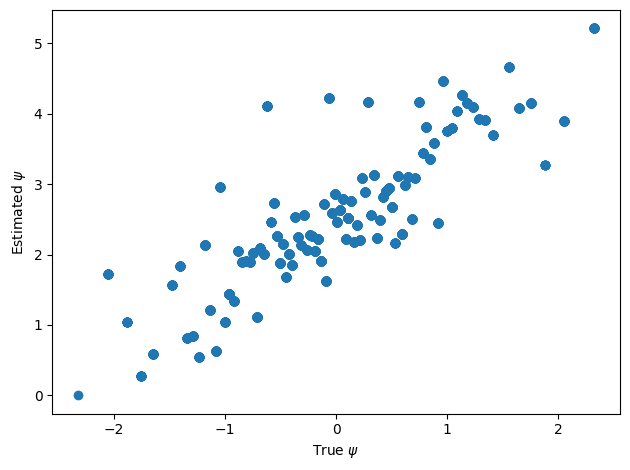

In [8]:
data = compute_akm(data)
plt.scatter(
    data['psi'],
    data['psi_hat'])
plt.xlabel('True $\psi$')
plt.ylabel('Estimated $\psi$')
plt.tight_layout()
plt.show()

### Use AKM estimate to construct variance decomposition



In [9]:
var_decomposition_hat = variance_decomposition(data, alpha_col="alpha_hat", psi_col="psi_hat", y_col="w")
display_variance_decomposition(var_decomposition_hat, text="Estimated model decomposition")


    Estimated model decomposition:

    \begin{array}{c c c c}
    Var(\alpha) & Var(\psi) & 2 Cov(\alpha,\psi)  & Var(\epsilon) \\
    \hline
    2.13 & 0.88 & -0.06 & 0.75 \\ \hline
    \end{array}
    

As we can see, while we simulated from a model which statifies all the assumption of AKM, the realized estimated decomposition is quite off. The variance of the firm effect is much larger and the covariance is much smaller, actually slightly negative.

### Monte-Carlo

We can simulate running the estimator on randomly drawn datasets to learn whether this was only due to the seed we used and this particular draw of the residuals.

We redraw the residuals, recompute the AKM estimates, and compare the average estimate to the true estimate. Because of the properties of OLS we expect this to be very well behaved in expectation.



In [10]:
reps = [
    compute_akm(model.draw_residuals(data))['psi_hat']
    for rep in range(50)]
psi_hat_mean = np.vstack(reps).mean(axis=0)
psi_hat_sd = np.vstack(reps).std(axis=0)

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_755/3514411854.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('True $\psi$')
/tmp/ipykernel_755/3514411854.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Estimated $\psi$')


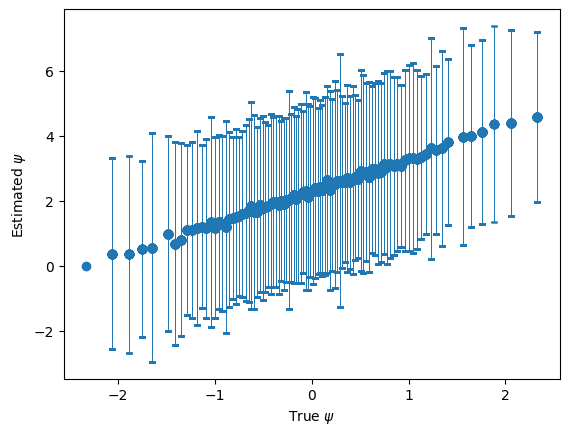

In [11]:
plt.errorbar(data['psi'], psi_hat_mean, yerr= 1.96 * psi_hat_sd, fmt='o', capsize=2, label='Psi with Error Bars', linewidth=0.5)

plt.xlabel('True $\psi$')
plt.ylabel('Estimated $\psi$')
plt.show()

We see in the previous graph that the $\psi$ lign up very well with the true one on average. However there is a lot of variation around the estimated values. Such variation contributes the estimated variance.

# How did we simulate the data?

We start with a couple of simple example. We generate homophily networks with 2 firms, 2 periods. Our first nework will be strongly segreated.



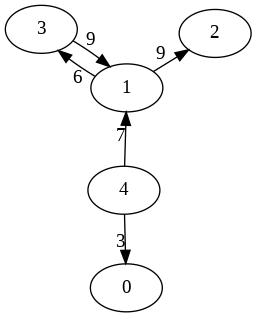

In [12]:
# @title Creating move graph from dataset

np.random.seed(7236)
p2 = Param( lambda1=0.5, rho = 2.0 , sigma=0.2, ng=10, nj=5)
model = Model(p2)
dataset = model.simulate(10,5)

dataset = dataset.sort_values(by=['i', 't'])
I = dataset['i'].to_numpy()
J = dataset['j'].to_numpy()

g = Digraph("G", engine="neato", filename="ex.gv", format="png")
g.attr(size="7")

for ii in range(1,len(I)):
  if (I[ii] != I[ii-1]):
    continue
  if (J[ii] != J[ii-1]):
    g.edge(str(J[ii-1]), str(J[ii]), label=str(I[ii]))
g.render("mygraph")
fname = "mygraph.png"
Image(fname)

We generate a simple homophily network. EAch period, with probably $\lambda$ individuals get an opportunity to change employer. They meet a firm $j'$ at random and choose according to a simple logit rule whether to move.

A worker $\gamma_i$ moves from firm $j$ to firm $j'$ with probability

$$ \frac{ \lambda }{n_j} G\left( \frac{ v_{ij} - v_{ij'} }{\sigma} \right)$$

with value being

$$ v_{ij} = (\gamma_i - \eta_{j})^2 $$

when working at firm $j$ we assume a log linear wage equation:

$$ w_{it} = \alpha_i + \psi_{j(i,t)} + \epsilon_{it} $$

where we draw the $\epsilon_{it}$ completely indepently at each $(i,t)$. We draw the $\alpha_i$ in relation to $\gamma_i$, when unerlated, we have no sorting, when positively related, we get positive sorting, and when negative, we get negative sorting. We use
$$\begin{align}
\alpha_i & = \rho \gamma_i + (1-\rho) u_i \\
\psi_j  & = \rho \eta_i + (1-\rho) z_i
\end{align}$$

We can see in the raw data (below) that indeed invidual 0 moves from firm 1 to firm 3 between t=1 and t=2.

In [13]:
dataset.head(10)

,i,j,t,alpha,psi,epsilon,w
0,0,1,0,1.487477,-0.38532,-0.068936,1.033220
1,0,1,1,1.487477,-0.38532,-0.243309,0.858848
2,0,1,2,1.487477,-0.38532,-0.069345,1.032812
3,0,1,3,1.487477,-0.38532,-0.115942,0.986215
4,0,1,4,1.487477,-0.38532,-0.186344,0.915813
5,1,3,0,1.979183,0.38532,0.125585,2.490089
6,1,3,1,1.979183,0.38532,-0.008635,2.355868
7,1,3,2,1.979183,0.38532,0.081777,2.446280
8,1,3,3,1.979183,0.38532,0.043003,2.407507
9,1,3,4,1.979183,0.38532,-0.298408,2.066095


Next we show what the matrix looks like for the mobility of the current dataset. You can see that the first 2 rows have ones for firm 1 (index starts at 0 in pyton) followed by ones in the fourth column.

In [14]:
M, Af, Aw = data_to_matrix(dataset)
Af[range(5),:]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

# Two way fixed effect estimator

We construct the matrices associated with the mobility of the workers. We then compute the least square estimates. Finally we compare the predicted $\psi$ to the true $\psi$ values. We do observe some noise.

In [15]:
np.random.seed(6344)
p3 = Param( lambda1=0.5, rho = 2.0 , sigma=0.2, ng=10, nj=100)
model = Model(p3)
dataset = model.simulate(1_000,5,connected=True)

M, Af, Aw = data_to_matrix(dataset)
MM = np.matmul(M.transpose(),M)
x = np.linalg.solve(MM, M.transpose() @ dataset['w'].to_numpy())

psi_jt = dataset['psi'].to_numpy()
alpha_jt = dataset['alpha'].to_numpy()
psi_hat = Af @ x[range(Af.shape[1])]
alpha_hat = Aw @ x[ range( Af.shape[1], Aw.shape[1]+Af.shape[1])]

Largest connected component: 100


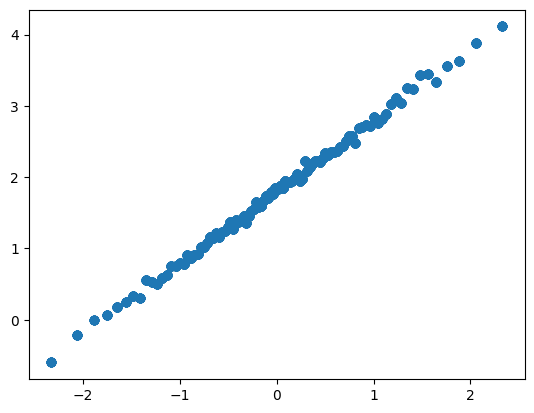

In [16]:
plt.scatter(
    psi_jt,
    psi_hat)
plt.show()

Largest connected component: 93
Largest connected component: 96
Largest connected component: 100
Largest connected component: 99
Largest connected component: 100
Largest connected component: 100
Largest connected component: 100
Largest connected component: 100
Largest connected component: 100
Largest connected component: 100


Text(0.5, 0, 'lambda1')

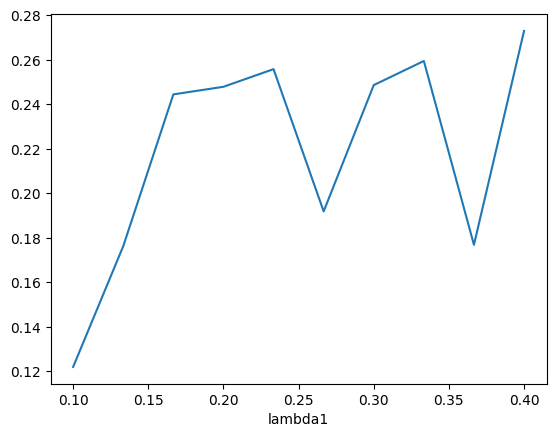

In [17]:
def get_cov(lambda1):
  ptmp = Param(lambda1 = lambda1, rho = 2.0 ,sigma = 0.2, ng = 10, nj = 100)
  model = Model(ptmp)
  dataset = model.simulate(1_000,5,connected=True)

  M, Af, Aw = data_to_matrix(dataset)
  MM = np.matmul(M.transpose(),M)
  x = np.linalg.solve(MM, M.transpose() @ dataset['w'].to_numpy())

  psi_jt = dataset['psi'].to_numpy()
  alpha_jt = dataset['alpha'].to_numpy()
  psi_hat = Af @ x[range(Af.shape[1])]
  alpha_hat = Aw @ x[ range( Af.shape[1], Aw.shape[1]+Af.shape[1])]
  return(np.cov(alpha_hat, psi_hat)[0,1])

lambda1_vals = np.linspace(0.1,0.4,10)
covs = [get_cov(l) for l in lambda1_vals]

plt.plot(lambda1_vals, covs)
plt.xlabel('lambda1')

In [18]:


template = Template(r"Hello, $name! Welcome to $place and $\alpha$")
formatted = template.safe_substitute(name="Alice", place="Wonderland")
print(formatted)


Hello, Alice! Welcome to Wonderland and $\alpha$


<div style="margin-top: 100px; margin-bottom: 20px;">This block has custom spacing.</div>
